# RQ2: preprocess, privately publish, and explore all sentiment datasets

This Colab notebook orchestrates the package preprocessing commands for **AIT V-oc, SST, IMDb, and DynaSent R1/R2**. It then verifies private Hugging Face visibility, reloads the artifacts, and runs descriptive quality checks.

The notebook intentionally keeps preprocessing logic in `sentiment_manifold`; notebook cells only configure, run, and inspect that tested code. SST, IMDb, and DynaSent are correctness-filtered with Pythia-2.8B before equal-length pairing. AIT is not correctness-filtered.

## Before running

1. In Colab, select **Runtime → Change runtime type → GPU**. An L4 or A100 is preferable; a T4 should work with a smaller batch but preprocessing will take longer.
2. When prompted, enter a Hugging Face token with write access. Input is hidden, cached only in notebook memory, and never printed or placed in a command argument.
3. Accept access conditions for any gated tokenizer used below (currently Gemma 2B), or remove that tokenizer from `PAIRING_MODELS`.
4. Place the three official tab-delimited AIT `.txt` files—`2018-Valence-oc-En-train.txt`, `2018-Valence-oc-En-dev.txt`, and `2018-Valence-oc-En-test-gold.txt`—in `My Drive/sentiment-manifold/data/ait/V-oc`. The notebook mounts Google Drive and reads them directly; no Colab frontend upload widget is used. Keep the files as plain text with tabs separating the four source columns.

**AIT redistribution warning.** The [official Affect in Tweets page](https://www.saifmohammad.com/WebPages/affectintweets.htm) places redistribution restrictions on the data. Private Hub visibility controls access but does not override those terms. AIT upload is therefore disabled unless you explicitly confirm that you have permission; local preprocessing and exploration remain available.

For a reportable run, replace branch names and `None` revisions in the settings cell with immutable commits. The preprocessors record resolved model/tokenizer revisions and source checksums in local metadata.

In [ ]:
# --------------------------- User settings ---------------------------
from pathlib import Path

CONTENT_ROOT = Path("/content")
PROJECT_URL = "https://github.com/Adefioye/sentiment-manifold.git"
PROJECT_REVISION = "main"  # Pin a commit SHA for a frozen run.
TIGGES_REFERENCE_URL = "https://github.com/curt-tigges/eliciting-latent-sentiment.git"
TIGGES_REFERENCE_REVISION = "037cbc9c18867e03da14ceace612ab7e0f9449f7"
DYNASENT_URL = "https://github.com/cgpotts/dynasent.git"
DYNASENT_REVISION = "main"  # Pin a commit SHA for a frozen run.

FILTER_MODEL = "pythia-2.8b"
FILTER_REVISION = None  # Optional immutable EleutherAI/pythia-2.8b revision.
FILTER_BATCH_SIZE = 8
PAIRING_MODELS = ["gpt2-small", "qwen-0.6b", "gemma-2b", "pythia-1.4b"]
PAIRING_REVISIONS = {model: None for model in PAIRING_MODELS}
MAX_PAIRING_PROMPT_TOKENS = 1000  # Full prompt length, including BOS; inclusive.
IMDB_REVISION = None  # Optional immutable stanfordnlp/imdb revision.

PUSH_TO_HUB = True
# Explicit user-controlled upload gate; this does not verify or grant redistribution rights.
AIT_HUB_UPLOAD_PERMISSION_ACKNOWLEDGED = True
REUSE_COMPLETED_LOCAL_OUTPUTS = True
SHOW_TEXT_SAMPLES = False  # Samples are opt-in and use training splits only.

# Directory containing the three official tab-delimited AIT .txt files.
# Google Drive is mounted at /content/drive; source text is read without modification.
DRIVE_MOUNT_ROOT = CONTENT_ROOT / "drive"
AIT_SOURCE = DRIVE_MOUNT_ROOT / "MyDrive/sentiment-manifold/data/ait/V-oc"

In [ ]:
# Helpers are defined before any setup command so the notebook is restart-safe.
import os
import shlex
import subprocess
import sys

# def checked_run(command, *, cwd=None, env=None):
#     print("$", shlex.join([str(part) for part in command]))
#     subprocess.run(
#         [str(part) for part in command], cwd=cwd, env=env, check=True
#     )

def checked_run(command, *, cwd=None, env=None):
    print("$", shlex.join([str(part) for part in command]))
    result = subprocess.run(
        [str(part) for part in command],
        cwd=cwd,
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(result.stdout[-20_000:])
    result.check_returncode()

def command_output(command, *, cwd=None):
    return subprocess.check_output(
        [str(part) for part in command], cwd=cwd, text=True
    ).strip()

def clone_at_revision(url, destination, revision):
    destination = Path(destination)
    if not (destination / ".git").is_dir():
        checked_run(["git", "clone", url, destination])
    if revision:
        checked_run(["git", "checkout", "--detach", revision], cwd=destination)
    resolved = command_output(["git", "rev-parse", "HEAD"], cwd=destination)
    print(f"Resolved {destination.name}: {resolved}")
    return resolved

# Part I: Colab preprocessing and publishing

Run Part I only when regenerating and publishing the processed datasets.

## 1. Install the project in the Colab runtime

A fresh Colab runtime is expected. Re-running this cell reuses existing clones and checks out the requested revisions without deleting local files.

In [ ]:
PROJECT_ROOT = CONTENT_ROOT / "sentiment-manifold"
PROJECT_COMMIT = clone_at_revision(PROJECT_URL, PROJECT_ROOT, PROJECT_REVISION)
checked_run([sys.executable, "-m", "pip", "install", "-q", "-e", f"{PROJECT_ROOT}[notebooks]"])

In [ ]:
# Authenticate without placing a token literal in the notebook.
import json
from collections import Counter
from functools import lru_cache
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from datasets import get_dataset_config_names, load_dataset, load_from_disk
from huggingface_hub import HfApi
from IPython.display import display
from getpass import getpass

_RUNTIME_SECRETS = {}

def get_runtime_secret(name):
    if name not in _RUNTIME_SECRETS:
        value = getpass(f"Enter {name} (input hidden): ").strip()
        if not value:
            raise RuntimeError(f"{name} was not provided.")
        _RUNTIME_SECRETS[name] = value
    return _RUNTIME_SECRETS[name]

def delete_runtime_secret(name):
    value = _RUNTIME_SECRETS.pop(name, None)
    if value is not None:
        del value

_token = get_runtime_secret("HF_TOKEN")
HF_ACCOUNT = HfApi(token=_token).whoami()["name"]
del _token
print("Hugging Face account:", HF_ACCOUNT)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Warning: Pythia-2.8B filtering will be very slow without a GPU.")

In [ ]:
# Private dataset destinations are derived from the authenticated account.
OUTPUTS = {
    "ait": PROJECT_ROOT / "data/processed/ait-valence-binary",
    "sst": PROJECT_ROOT / "data/processed/sst-pythia-2.8b",
    "imdb": PROJECT_ROOT / "data/processed/imdb-pythia-2.8b",
    "dynasent": PROJECT_ROOT / "data/processed/dynasent-r1-r2-pythia-2.8b",
}
REPOS = {
    "ait": f"{HF_ACCOUNT}/sentiment-manifold-ait-valence-binary",
    "sst": f"{HF_ACCOUNT}/sentiment-manifold-sst-pythia-2.8b",
    "imdb": f"{HF_ACCOUNT}/sentiment-manifold-imdb-pythia-2.8b",
    "dynasent": f"{HF_ACCOUNT}/sentiment-manifold-dynasent-r1-r2-pythia-2.8b",
}
SHOULD_PUSH = {
    key: PUSH_TO_HUB and (key != "ait" or AIT_HUB_UPLOAD_PERMISSION_ACKNOWLEDGED)
    for key in OUTPUTS
}
display(pd.DataFrame({"local_output": OUTPUTS, "hub_repo": REPOS, "will_push": SHOULD_PUSH}))

In [ ]:
from pathlib import Path
import importlib
import subprocess
import sys

PROJECT_ROOT = Path("/content/sentiment-manifold")

assert (PROJECT_ROOT / "pyproject.toml").is_file(), (
    "Project was not cloned. Rerun the notebook's clone/install cell first."
)

# Show installation errors instead of suppressing them with -q.
subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-e",
        f"{PROJECT_ROOT}[notebooks]",
    ],
    check=True,
)

# Make the editable source visible immediately without restarting the kernel.
project_src = str(PROJECT_ROOT / "src")
if project_src not in sys.path:
    sys.path.insert(0, project_src)

importlib.invalidate_caches()

import sentiment_manifold
print("Imported from:", sentiment_manifold.__file__)

## 2. Acquire and validate source data

SST is read from the commit-pinned Tigges et al. reference repository. DynaSent is extracted from the official repository archive. IMDb is downloaded by the package from Hugging Face. AIT must be obtained under its source terms and placed at `My Drive/sentiment-manifold/data/ait/V-oc`; the notebook mounts Drive and reads it from `AIT_SOURCE`.

In [ ]:
REFERENCE_ROOT = CONTENT_ROOT / "eliciting-latent-sentiment"
DYNASENT_REPOSITORY = CONTENT_ROOT / "dynasent-source"
TIGGES_REFERENCE_COMMIT = clone_at_revision(
    TIGGES_REFERENCE_URL, REFERENCE_ROOT, TIGGES_REFERENCE_REVISION
)
DYNASENT_COMMIT = clone_at_revision(
    DYNASENT_URL, DYNASENT_REPOSITORY, DYNASENT_REVISION
)

SST_ROOT = REFERENCE_ROOT / "stanfordSentimentTreebank"
DYNASENT_ROOT = CONTENT_ROOT / "data/raw/dynasent"
DYNASENT_ROOT.mkdir(parents=True, exist_ok=True)
dynasent_archives = list(DYNASENT_REPOSITORY.rglob("dynasent-v1.1.zip"))
if len(dynasent_archives) != 1:
    raise FileNotFoundError("Expected exactly one dynasent-v1.1.zip in the official repository")
with zipfile.ZipFile(dynasent_archives[0]) as archive:
    archive.extractall(DYNASENT_ROOT)
print("SST source:", SST_ROOT)
print("DynaSent source:", DYNASENT_ROOT)

In [ ]:
# Mount Google Drive, then resolve the official English AIT Valence-oc
# train, dev, and test-gold files directly from My Drive.
from google.colab import drive
from sentiment_manifold.data.preprocessing.ait import discover_ait_files

if not (DRIVE_MOUNT_ROOT / "MyDrive").is_dir():
    drive.mount(str(DRIVE_MOUNT_ROOT), force_remount=False)
else:
    print(f"Google Drive is already mounted at {DRIVE_MOUNT_ROOT}")

AIT_SOURCE = Path(AIT_SOURCE).expanduser()
if not AIT_SOURCE.exists():
    raise FileNotFoundError(
        f"AIT_SOURCE does not exist: {AIT_SOURCE}. "
        "Confirm the extracted files are in My Drive/sentiment-manifold/data/ait/V-oc "
        "or update AIT_SOURCE in the settings cell."
    )

if AIT_SOURCE.is_dir():
    AIT_ROOT = AIT_SOURCE
elif zipfile.is_zipfile(AIT_SOURCE):
    # Extract only an archive obtained from a trusted official source.
    AIT_ROOT = CONTENT_ROOT / "data/raw/ait"
    AIT_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(AIT_SOURCE) as archive:
        archive.extractall(AIT_ROOT)
else:
    raise ValueError(f"AIT_SOURCE must be a directory or ZIP archive: {AIT_SOURCE}")

try:
    AIT_FILES = discover_ait_files(AIT_ROOT)
except FileNotFoundError as exc:
    raise FileNotFoundError(
        f"Could not find all three English AIT V-oc splits under {AIT_ROOT}. "
        "Expected 2018-Valence-oc-En-{train,dev,test-gold}.txt."
    ) from exc

print("Discovered AIT splits:")
for split, path in AIT_FILES.items():
    print(f"  {split}: {path.name}")

In [ ]:
# Fail early if source discovery is incomplete. No preprocessing has run yet.
from sentiment_manifold.data.preprocessing.dynasent import discover_dynasent_files

if not SST_ROOT.is_dir():
    raise FileNotFoundError(SST_ROOT)
DYNASENT_FILES = discover_dynasent_files(DYNASENT_ROOT, rounds=(1, 2))
assert set(AIT_FILES) == {"train", "dev", "test"}
assert len(DYNASENT_FILES) == 6
print("Source validation passed: AIT=3 splits, DynaSent=6 round/split files, SST present.")

## 3. Preprocess and publish

Each command writes one local directory containing named Hugging Face `DatasetDict` configurations, `metadata.json`, and a dataset card. If publishing is enabled for that dataset, every configuration is pushed to the specified **private** repository.

The Pythia-2.8B process exits between SST, IMDb, and DynaSent, releasing GPU memory. Model downloads remain cached by Colab.

In [ ]:
def pairing_arguments():
    arguments = ["--max-pairing-prompt-tokens", str(MAX_PAIRING_PROMPT_TOKENS)]
    for model in PAIRING_MODELS:
        arguments.extend(["--pairing-model", model])
        revision = PAIRING_REVISIONS.get(model)
        if revision:
            arguments.extend(["--pairing-revision", f"{model}={revision}"])
    return arguments

def filter_arguments():
    arguments = [
        "--filter-model", FILTER_MODEL,
        "--device", "auto",
        "--dtype", "auto",
        "--batch-size", str(FILTER_BATCH_SIZE),
    ]
    if FILTER_REVISION:
        arguments.extend(["--filter-revision", FILTER_REVISION])
    return arguments

def publish_arguments(dataset_key):
    if not SHOULD_PUSH[dataset_key]:
        return []
    return ["--push-to-hub", "--private", "--hub-repo-id", REPOS[dataset_key]]

def run_preprocessor(dataset_key, subcommand, arguments):
    metadata_path = OUTPUTS[dataset_key] / "metadata.json"
    if REUSE_COMPLETED_LOCAL_OUTPUTS and metadata_path.is_file():
        print(f"Reusing completed local artifact: {OUTPUTS[dataset_key]}")
        print("Set REUSE_COMPLETED_LOCAL_OUTPUTS=False and remove that directory to regenerate.")
        return
    command = [
        sys.executable, "-m", "sentiment_manifold.cli", subcommand,
        "--output-dir", OUTPUTS[dataset_key],
        *arguments,
        *pairing_arguments(),
        *publish_arguments(dataset_key),
    ]
    child_env = os.environ.copy()
    child_env["HF_TOKEN"] = get_runtime_secret("HF_TOKEN")
    child_env["HF_HUB_DISABLE_TELEMETRY"] = "1"
    try:
        checked_run(command, cwd=PROJECT_ROOT, env=child_env)
    finally:
        child_env.pop("HF_TOKEN", None)
        del child_env

In [ ]:
# AIT: preserve ordinal valence, exclude zero, map negative/positive classes, and pair.
# Deliberately no correctness-filter arguments are used for AIT.
if PUSH_TO_HUB and not AIT_HUB_UPLOAD_PERMISSION_ACKNOWLEDGED:
    print("AIT will remain local because upload permission was not acknowledged.")
run_preprocessor("ait", "preprocess-ait", ["--ait-root", AIT_ROOT])

In [ ]:
# SST: build both label-policy variants; only test is Pythia-filtered and paired.
run_preprocessor(
    "sst",
    "preprocess-sst",
    ["--sst-root", SST_ROOT, "--binarization", "both", *filter_arguments()],
)

In [ ]:
# IMDb: retain source labels/text; only test is Pythia-filtered and paired by default.
imdb_arguments = ["--dataset-name", "stanfordnlp/imdb", *filter_arguments()]
if IMDB_REVISION:
    imdb_arguments.extend(["--dataset-revision", IMDB_REVISION])
run_preprocessor("imdb", "preprocess-imdb", imdb_arguments)

In [ ]:
# DynaSent: keep rounds separate; only gold positive/negative test records are filtered/paired.
run_preprocessor(
    "dynasent",
    "preprocess-dynasent",
    ["--dynasent-root", DYNASENT_ROOT, *filter_arguments()],
)

# Part II: standalone local exploration

Part II can be run by itself on a local Mac. It does not require Part I, `/content`, Google Drive, this repository, or any Git clone. Install its lightweight dependencies once with `python -m pip install datasets huggingface-hub pandas matplotlib seaborn ipython`, then start with the next setup cell.

The loader selects Parquet files from each configuration directory explicitly. This prevents a malformed or stale Hub dataset card from mixing `binary` and pair schemas. These are **descriptive preprocessing checks**, not evidence of a causal mechanism. Do not use locked test results to choose layers, fitters, intervention strengths, or other hyperparameters.

In [14]:
# ------------------ Standalone exploration setup ------------------
import json
import os
from collections import Counter
from functools import lru_cache
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from huggingface_hub import HfApi, get_token, hf_hub_download
from IPython.display import display

SHOW_TEXT_SAMPLES = False
DATASET_ACCOUNT = os.environ.get("SENTIMENT_MANIFOLD_DATASET_ACCOUNT", "kokolamba")
REPOS = {
    "ait": f"{DATASET_ACCOUNT}/sentiment-manifold-ait-valence-binary",
    "sst": f"{DATASET_ACCOUNT}/sentiment-manifold-sst-pythia-2.8b",
    "imdb": f"{DATASET_ACCOUNT}/sentiment-manifold-imdb-pythia-2.8b",
    "dynasent": f"{DATASET_ACCOUNT}/sentiment-manifold-dynasent-r1-r2-pythia-2.8b",
}
SUMMARY_DIR = Path.cwd() / "rq2-data-exploration"

def get_exploration_token():
    token = globals().get("_EXPLORATION_TOKEN")
    if not token:
        token = os.environ.get("HF_TOKEN") or get_token()
    if not token:
        token = getpass("Enter HF_TOKEN (input hidden): ").strip()
    if not token:
        raise RuntimeError("A Hugging Face token is required for the private datasets.")
    globals()["_EXPLORATION_TOKEN"] = token
    return token

_EXPLORATION_API = HfApi(token=get_exploration_token())
print("Authenticated as:", _EXPLORATION_API.whoami()["name"])
print("Dataset account:", DATASET_ACCOUNT)

Authenticated as: kokolamba
Dataset account: kokolamba


In [15]:
# Pin remote repositories and summarize Hub provenance before examining examples.
_EXPLORATION_API = HfApi(token=get_exploration_token())
REPO_INFO = {}
REPO_FILES = {}
HUB_METADATA = {}
privacy_rows = []
provenance_rows = []
for key, repo_id in REPOS.items():
    info = _EXPLORATION_API.repo_info(
        repo_id, repo_type="dataset"
    )
    if info.private is not True:
        raise RuntimeError(f"Expected a private dataset repository: {repo_id}")
    revision = info.sha
    files = _EXPLORATION_API.list_repo_files(
        repo_id, repo_type="dataset", revision=revision
    )
    REPO_INFO[key] = info
    REPO_FILES[key] = files
    config_names = sorted({
        path.split("/", 1)[0]
        for path in files
        if "/" in path and path.endswith(".parquet")
    })
    metadata = {}
    if "metadata.json" in files:
        metadata_file = hf_hub_download(
            repo_id, "metadata.json", repo_type="dataset",
            revision=revision, token=get_exploration_token(),
        )
        metadata = json.loads(Path(metadata_file).read_text())
    HUB_METADATA[key] = metadata
    correctness = metadata.get("correctness_filter", {})
    privacy_rows.append({
        "dataset": key, "repo": repo_id, "status": "private",
        "revision": revision,
    })
    provenance_rows.append({
        "dataset": key,
        "hub_revision": revision,
        "metadata": "available" if metadata else "not published",
        "filter": correctness.get("filter_model_alias", "none"),
        "filter_revision": correctness.get("resolved_filter_model_revision"),
        "pairing_models": ", ".join(metadata.get("pairing_models", [])),
        "configs": len(config_names),
    })
PRIVACY_TABLE = pd.DataFrame(privacy_rows)
PROVENANCE_TABLE = pd.DataFrame(provenance_rows)
display(PROVENANCE_TABLE)
display(PRIVACY_TABLE)

,dataset,hub_revision,metadata,filter,filter_revision,pairing_models,configs
0,ait,c53df7c117c2f433df904cfaeddb9062027f755f,not published,none,None,,12
1,sst,bcffb933a34a48b409a7caf3a53f0fe7bb8152cc,not published,none,None,,32
2,imdb,64c7eb3003a72c4ddb711bec1450248d71d35493,not published,none,None,,14
3,dynasent,f4aa6cc90bfeda2080e6445592a8f689c974fd3d,not published,none,None,,28


,dataset,repo,status,revision
0,ait,kokolamba/sentiment-manifold-ait-valence-binary,private,c53df7c117c2f433df904cfaeddb9062027f755f
1,sst,kokolamba/sentiment-manifold-sst-pythia-2.8b,private,bcffb933a34a48b409a7caf3a53f0fe7bb8152cc
2,imdb,kokolamba/sentiment-manifold-imdb-pythia-2.8b,private,64c7eb3003a72c4ddb711bec1450248d71d35493
3,dynasent,kokolamba/sentiment-manifold-dynasent-r1-r2-py...,private,f4aa6cc90bfeda2080e6445592a8f689c974fd3d


## Load configuration-isolated artifacts

Each configuration is downloaded from its own Hub directory and loaded as Parquet. This works with both corrected repositories and repositories published before the dataset-card fix.

In [16]:
def available_configs(dataset_key):
    return sorted({
        path.split("/", 1)[0]
        for path in REPO_FILES[dataset_key]
        if "/" in path and path.endswith(".parquet")
    })

@lru_cache(maxsize=None)
def load_processed(dataset_key, config_name):
    repo_id = REPOS[dataset_key]
    revision = REPO_INFO[dataset_key].sha
    prefix = f"{config_name}/"
    config_files = [
        path for path in REPO_FILES[dataset_key]
        if path.startswith(prefix) and path.endswith(".parquet")
    ]
    if not config_files:
        raise FileNotFoundError(f"No Parquet files for {repo_id}/{config_name}")
    data_files = {}
    for remote_path in config_files:
        split = Path(remote_path).name.split("-", 1)[0]
        if split not in {"train", "validation", "test"}:
            raise ValueError(f"Cannot infer split from {remote_path}")
        local_path = hf_hub_download(
            repo_id, remote_path, repo_type="dataset",
            revision=revision, token=get_exploration_token(),
        )
        data_files.setdefault(split, []).append(local_path)
    return load_dataset("parquet", data_files=data_files)

CONFIGS = {key: available_configs(key) for key in REPOS}
config_rows = [
    {"dataset": key, "configuration": config}
    for key, configs in CONFIGS.items()
    for config in configs
]
CONFIG_TABLE = pd.DataFrame(config_rows)
display(CONFIG_TABLE.groupby("dataset").agg(
    configuration_count=("configuration", "count"),
    configurations=("configuration", lambda values: ", ".join(values)),
))

,configuration_count,configurations
dataset,,
ait,12,"binary, common_directed_pairs, common_matched_..."
dynasent,28,"r1_binary, r1_common_directed_pairs, r1_common..."
imdb,14,"binary, common_directed_pairs, common_matched_..."
sst,32,"neutral_removed_binarized, neutral_removed_com..."


### Label balance

This checks the ground-truth binary labels in each retained split. It does not treat the labels as model predictions. Large imbalances should be recorded because they affect fitters and uncertainty estimates.

In [17]:
BINARY_CONFIGS = {
    "ait": ["binary"],
    "sst": ["tigges_binarized", "neutral_removed_binarized"],
    "imdb": ["binary"],
    "dynasent": ["r1_binary", "r2_binary"],
}
label_rows = []
for dataset_key, config_names in BINARY_CONFIGS.items():
    for config_name in config_names:
        artifact = load_processed(dataset_key, config_name)
        for split, records in artifact.items():
            counts = Counter(int(label) for label in records["label"])
            for label, label_name in ((0, "negative"), (1, "positive")):
                label_rows.append({
                    "dataset": dataset_key, "configuration": config_name,
                    "split": split, "label": label_name, "rows": counts[label],
                })
LABEL_TABLE = pd.DataFrame(label_rows)
display(LABEL_TABLE.pivot_table(
    index=["dataset", "configuration", "split"],
    columns="label", values="rows", fill_value=0,
))

label                                          negative  positive
dataset  configuration             split                         
ait      binary                    test           340.0     335.0
                                   train          456.0     384.0
                                   validation     198.0     146.0
dynasent r1_binary                 test          1200.0    1200.0
                                   train        14021.0   21391.0
                                   validation    1200.0    1200.0
         r2_binary                 test           240.0     240.0
                                   train         4579.0    6038.0
                                   validation     240.0     240.0
imdb     binary                    test         12500.0   12500.0
                                   train        12500.0   12500.0
sst      neutral_removed_binarized test           834.0     858.0
                                   train         3006.0    3362.0
                                   validation     391.0     406.0
         tigges_binarized          test          1045.0    1013.0
                                   train         3872.0    3992.0
                                   validation     508.0     499.0

### Pythia-2.8B correctness-gate retention

For SST, IMDb, and DynaSent, labels stay equal to dataset ground truth. The binary labels only determine whether Pythia's larger `Positive`/`Negative` logit agrees with the example; they never relabel it. The retention rate below is therefore a preprocessing audit, not a directional-patching metric.

,dataset,configuration,scored,retained_correct,retention_percent
0,sst,tigges,2058,1163,56.51
1,sst,neutral_removed,1692,1001,59.16
2,imdb,pythia_scored,24996,20533,82.15
3,dynasent,r1,2400,1238,51.58
4,dynasent,r2,480,272,56.67


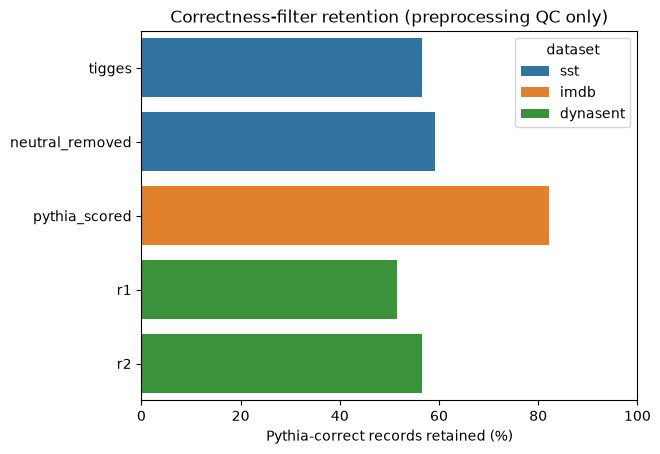

In [18]:
GATE_CONFIGS = [
    ("sst", "tigges_pythia_scored", "tigges_pythia_correct", "test"),
    ("sst", "neutral_removed_pythia_scored", "neutral_removed_pythia_correct", "test"),
    ("imdb", "pythia_scored", "pythia_correct", "test"),
    ("dynasent", "r1_pythia_scored", "r1_pythia_correct", "test"),
    ("dynasent", "r2_pythia_scored", "r2_pythia_correct", "test"),
]
gate_rows = []
for dataset_key, scored_config, correct_config, split in GATE_CONFIGS:
    scored = len(load_processed(dataset_key, scored_config)[split])
    correct = len(load_processed(dataset_key, correct_config)[split])
    gate_rows.append({
        "dataset": dataset_key, "configuration": scored_config.removesuffix("_pythia_scored"),
        "scored": scored, "retained_correct": correct,
        "retention_percent": 100.0 * correct / scored if scored else float("nan"),
    })
GATE_TABLE = pd.DataFrame(gate_rows)
display(GATE_TABLE.round(2))
sns.barplot(data=GATE_TABLE, x="retention_percent", y="configuration", hue="dataset")
plt.xlim(0, 100)
plt.xlabel("Pythia-correct records retained (%)")
plt.ylabel("")
plt.title("Correctness-filter retention (preprocessing QC only)")
plt.show()

### Equal-length pair coverage for GPT-2, Qwen, and the common intersection

A matched pair contains one positive and one negative prompt with equal **full-prompt** length for the named tokenizer. `common` requires equality for all selected tokenizers. Its count should therefore be no larger than any individual-model count.

pairing,Common,GPT-2 Small,Qwen3 0.6B
dataset,,,
AIT,117,693,715
DynaSent R1,24,40,40
DynaSent R2,22,33,34
IMDb,243,7645,7676
SST (Tigges labels),64,152,151


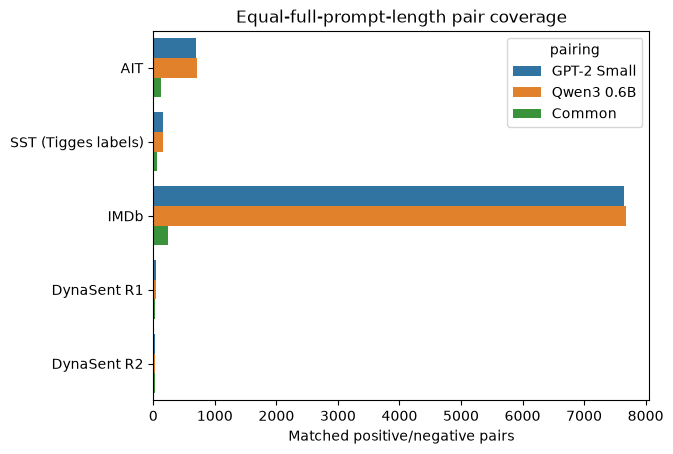

In [19]:
PAIR_DATASETS = [
    ("ait", "AIT", ""),
    ("sst", "SST (Tigges labels)", "tigges_"),
    ("imdb", "IMDb", ""),
    ("dynasent", "DynaSent R1", "r1_"),
    ("dynasent", "DynaSent R2", "r2_"),
]
PAIRING_PREFIXES = {"GPT-2 Small": "gpt2_small", "Qwen3 0.6B": "qwen_0_6b", "Common": "common"}
pair_rows = []
for dataset_key, display_name, dataset_prefix in PAIR_DATASETS:
    for model_name, model_prefix in PAIRING_PREFIXES.items():
        config_name = f"{dataset_prefix}{model_prefix}_matched_pairs"
        artifact = load_processed(dataset_key, config_name)
        pair_rows.append({
            "dataset": display_name, "pairing": model_name,
            "matched_pairs": sum(len(records) for records in artifact.values()),
        })
PAIR_TABLE = pd.DataFrame(pair_rows)
display(PAIR_TABLE.pivot(index="dataset", columns="pairing", values="matched_pairs"))
sns.barplot(data=PAIR_TABLE, x="matched_pairs", y="dataset", hue="pairing")
plt.xlabel("Matched positive/negative pairs")
plt.ylabel("")
plt.title("Equal-full-prompt-length pair coverage")
plt.show()

### Directed-pair invariant checks

Every matched pair must expand to exactly two causal cases: negative receiver with positive donor, and positive receiver with negative donor. Labels define those roles; the eventual logit-flip and normalized logit-difference metrics must be computed from model outputs after intervention, not from the labels themselves.

In [20]:
invariant_rows = []
for dataset_key, display_name, dataset_prefix in PAIR_DATASETS:
    for model_name, model_prefix in PAIRING_PREFIXES.items():
        config_name = f"{dataset_prefix}{model_prefix}_directed_pairs"
        artifact = load_processed(dataset_key, config_name)
        case_count = 0
        pair_counts = Counter()
        signatures = {}
        for records in artifact.values():
            length_columns = [name for name in records.column_names if name.endswith("_prompt_num_tokens")]
            if not length_columns:
                raise AssertionError(f"No prompt-length field in {config_name}")
            for row in records:
                if int(row["source_label"]) == int(row["target_label"]):
                    raise AssertionError(f"Same-label causal pair in {config_name}")
                pair_id = row["pair_id"]
                signature = tuple(int(row[name]) for name in length_columns)
                if pair_id in signatures and signatures[pair_id] != signature:
                    raise AssertionError(f"Length signature changed within {pair_id}")
                signatures[pair_id] = signature
                pair_counts[pair_id] += 1
                case_count += 1
        if any(count != 2 for count in pair_counts.values()):
            raise AssertionError(f"A directed pair did not have two cases in {config_name}")
        invariant_rows.append({
            "dataset": display_name, "pairing": model_name,
            "matched_pairs": len(pair_counts), "directed_cases": case_count, "status": "passed",
        })
INVARIANT_TABLE = pd.DataFrame(invariant_rows)
display(INVARIANT_TABLE)

,dataset,pairing,matched_pairs,directed_cases,status
0,AIT,GPT-2 Small,693,1386,passed
1,AIT,Qwen3 0.6B,715,1430,passed
2,AIT,Common,117,234,passed
3,SST (Tigges labels),GPT-2 Small,152,304,passed
4,SST (Tigges labels),Qwen3 0.6B,151,302,passed
5,SST (Tigges labels),Common,64,128,passed
6,IMDb,GPT-2 Small,7645,15290,passed
7,IMDb,Qwen3 0.6B,7676,15352,passed
8,IMDb,Common,243,486,passed
9,DynaSent R1,GPT-2 Small,40,80,passed


### AIT ordinal valence distribution (development data only)

AIT's `original_valence_class` is an ordered category from −3 to +3, not an interval-scale continuous target. Zero is excluded by the binary policy. Only train and validation are shown so the final test split remains locked for confirmation.

,split,ordinal_class,rows
0,train,-3,129
1,train,-2,249
2,train,-1,78
3,train,1,167
4,train,2,92
5,train,3,125
6,validation,-3,69
7,validation,-2,95
8,validation,-1,34
9,validation,1,58


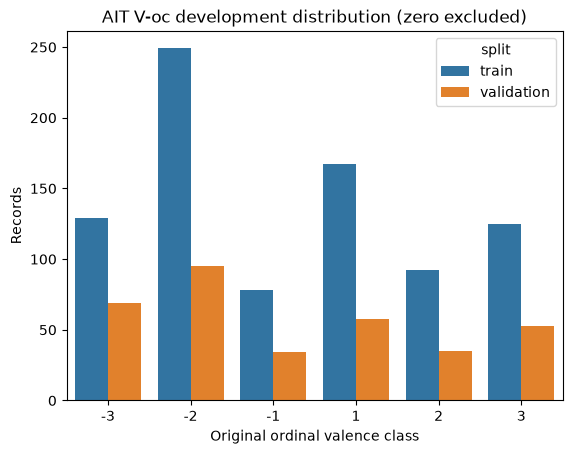

In [21]:
ait_binary = load_processed("ait", "binary")
ait_valence_rows = []
for split in ("train", "validation"):
    counts = Counter(int(value) for value in ait_binary[split]["original_valence_class"])
    for ordinal_class, rows in sorted(counts.items()):
        ait_valence_rows.append({"split": split, "ordinal_class": ordinal_class, "rows": rows})
AIT_VALENCE_TABLE = pd.DataFrame(ait_valence_rows)
display(AIT_VALENCE_TABLE)
sns.barplot(data=AIT_VALENCE_TABLE, x="ordinal_class", y="rows", hue="split")
plt.xlabel("Original ordinal valence class")
plt.ylabel("Records")
plt.title("AIT V-oc development distribution (zero excluded)")
plt.show()

In [22]:
# Optional schema/text inspection. It is off by default and samples only training data.
# This is useful for formatting checks, not for choosing models or interventions.
SHOW_TEXT_SAMPLES = True
if SHOW_TEXT_SAMPLES:
    sample_specs = [
        ("ait", "binary"), ("sst", "tigges_binarized"),
        ("imdb", "binary"), ("dynasent", "r1_binary"),
    ]
    for dataset_key, config_name in sample_specs:
        records = load_processed(dataset_key, config_name)["train"]
        row = records.shuffle(seed=42).select([0])[0]
        print(f"\n{dataset_key} / {config_name}")
        print("columns:", records.column_names)
        print("label:", row["label"], "text preview:", row["text"][:240])
else:
    print("Text sampling is disabled. Set SHOW_TEXT_SAMPLES=True to inspect fixed-seed training examples.")


ait / binary
columns: ['example_id', 'source_example_id', 'text', 'label', 'label_name', 'split', 'original_valence_class', 'annotation_scale', 'binary_policy']
label: 1 text preview: Come to the @BullSkitComedy FUNdraiser this Fri. at 8pm @TheScottBlock. Because #pie + #face = !

sst / tigges_binarized
columns: ['example_id', 'sentence_index', 'phrase_id', 'text', 'sentiment_score', 'original_label_5', 'label', 'label_name', 'split', 'is_neutral_removed', 'binarization_method']
label: 0 text preview: It's quite an achievement to set and shoot a movie at the Cannes Film Festival and yet fail to capture its visual appeal or its atmosphere.

imdb / binary
columns: ['example_id', 'text', 'label', 'label_name', 'split', 'source_row_index']
label: 1 text preview: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more com

In [24]:
# Save small, shareable summaries. These CSVs contain counts/provenance only, not source text.
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
summary_tables = {
    "provenance.csv": PROVENANCE_TABLE,
    "privacy.csv": PRIVACY_TABLE,
    "configurations.csv": CONFIG_TABLE,
    "label_counts.csv": LABEL_TABLE,
    "correctness_gate.csv": GATE_TABLE,
    "pair_coverage.csv": PAIR_TABLE,
    "pair_invariants.csv": INVARIANT_TABLE,
    "ait_development_valence_counts.csv": AIT_VALENCE_TABLE,
}
for filename, table in summary_tables.items():
    table.to_csv(SUMMARY_DIR / filename, index=False)
print("Saved exploration summaries to", SUMMARY_DIR)

Saved exploration summaries to /Users/abdulhakeemadefioye/Desktop/neural-geometry/sentiment-manifold/notebooks/rq2-data-exploration


## Remove the Hugging Face token from memory

Run the next cell when publishing and private-data exploration are complete—or at any time you want to forget the cached credential. A later Hub operation will prompt for the token again.

In [25]:
# Clear notebook-owned credentials and downloaded Dataset objects.
if "load_processed" in globals():
    load_processed.cache_clear()
if "_EXPLORATION_TOKEN" in globals():
    del _EXPLORATION_TOKEN
if "_EXPLORATION_API" in globals():
    del _EXPLORATION_API
if "_RUNTIME_SECRETS" in globals():
    delete_runtime_secret("HF_TOKEN")
print("Cleared notebook-managed Hugging Face credentials and dataset cache.")

Cleared notebook-managed Hugging Face credentials and dataset cache.


In [26]:
# An HF_TOKEN inherited from your shell remains managed by the shell.
print("HF_TOKEN environment variable present:", bool(os.environ.get("HF_TOKEN")))

HF_TOKEN environment variable present: True


## Interpretation boundary

Passing these checks establishes dataset provenance, label counts, correctness-filter retention, and equal-length causal-pair structure. It does **not** establish that a learned direction is causal. Direction fitting must use training activations, layer/hyperparameter selection must use validation data, and final test/OOD evaluation must stay locked until confirmation. Causal conclusions additionally require directional patching and controls.